<a href="https://colab.research.google.com/github/aparna-2001/machine_learning_using_python/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [4]:
wsb_df = pd.read_csv('wsb.csv')
wsb_df.head(10)

,Month,Sale Quantity,Promotion Expenses,Competition Promotion
0,1,3002666,105,1
1,2,4401553,145,0
2,3,3205279,118,1
3,4,4245349,130,0
4,5,3001940,98,1
5,6,4377766,156,0
6,7,2798343,98,1
7,8,4303668,144,0
8,9,2958185,112,1
9,10,3623386,120,0


In [5]:
wsb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Month                  48 non-null     int64
 1   Sale Quantity          48 non-null     int64
 2   Promotion Expenses     48 non-null     int64
 3   Competition Promotion  48 non-null     int64
dtypes: int64(4)
memory usage: 1.6 KB


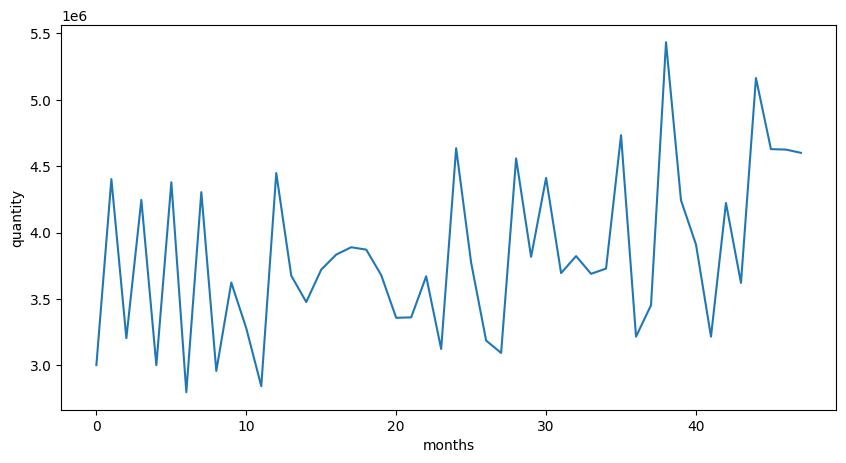

In [9]:

plt.figure(figsize=(10,5))
plt.xlabel('months')
plt.ylabel('quantity')


plt.plot(wsb_df['Sale Quantity'])

*forecasting using moving average*

In [13]:
wsb_df['mv_12'] = wsb_df['Sale Quantity'].rolling(12).mean().shift(1)
wsb_df.head(10)

,Month,Sale Quantity,Promotion Expenses,Competition Promotion,mv_12
0,1,3002666,105,1,NaN
1,2,4401553,145,0,NaN
2,3,3205279,118,1,NaN
3,4,4245349,130,0,NaN
4,5,3001940,98,1,NaN
5,6,4377766,156,0,NaN
6,7,2798343,98,1,NaN
7,8,4303668,144,0,NaN
8,9,2958185,112,1,NaN
9,10,3623386,120,0,NaN


In [14]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
wsb_df[['Sale Quantity', 'mv_12']][36:]

,Sale Quantity,mv_12
36,3216483,3928410.33
37,3453239,3810280.00
38,5431651,3783643.33
39,4241851,3970688.42
40,3909887,4066369.08
41,3216438,4012412.75
42,4222005,3962369.58
43,3621034,3946629.42
44,5162201,3940489.50
45,4627177,4052117.17


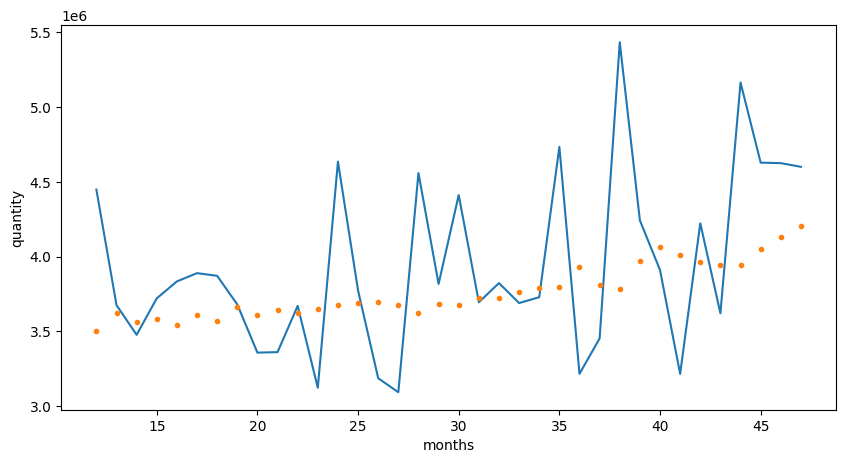

In [18]:
plt.figure(figsize=(10,5))

plt.xlabel('months')
plt.ylabel('quantity')

plt.plot(wsb_df['Sale Quantity'][12:])
plt.plot(wsb_df['mv_12'][12:],'.')

*Forecasting accuracy* (of moving average)

   * MAPE
   * RMSE

*MAPE*

In [19]:
def get_mape(actual, predicted):
   y_true, y_pred = np.array(actual), np.array(predicted)
   return np.round(np.mean(np.abs((actual-predicted)/actual))*100, 2)

In [21]:
get_mape(wsb_df['Sale Quantity'][36:].values, wsb_df['mv_12'][36:].values)

np.float64(14.04)

*RMSE*

In [23]:
np.sqrt(mean_squared_error(wsb_df['Sale Quantity'][36:].values, wsb_df['mv_12'][36:].values))

np.float64(734725.8359239782)

*Exponential smoothing*

In [26]:
wsb_df['ewm'] = wsb_df['Sale Quantity'].ewm(alpha=0.2).mean()
pd.options.display.float_format = '{:.2f}'.format
wsb_df[36:]

,Month,Sale Quantity,Promotion Expenses,Competition Promotion,mv_12,ewm
36,37,3216483,121,1,3928410.33,3828234.64
37,38,3453239,128,0,3810280.00,3753219.93
38,39,5431651,170,0,3783643.33,4088961.93
39,40,4241851,160,0,3970688.42,4119543.81
40,41,3909887,151,1,4066369.08,4077607.99
41,42,3216438,120,1,4012412.75,3905359.34
42,43,4222005,152,0,3962369.58,3968692.78
43,44,3621034,125,0,3946629.42,3899157.24
44,45,5162201,170,0,3940489.50,4151776.99
45,46,4627177,160,0,4052117.17,4246860.31


*Forecasting accuracy* (of exponential smoothing)

   * MAPE
   * RMSE

In [27]:
get_mape(wsb_df['Sale Quantity'][36:].values, wsb_df['ewm'][36:].values)

np.float64(11.15)

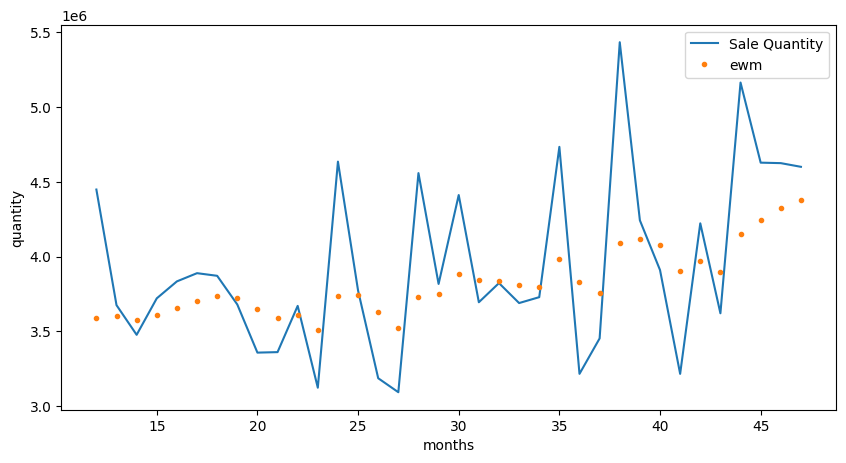

In [34]:
plt.figure(figsize=(10,5))

plt.xlabel('months')
plt.ylabel('quantity')


plt.plot(wsb_df['Sale Quantity'][12:], label = 'Sale Quantity')
plt.plot(wsb_df['ewm'][12:],'.', label = 'ewm')

plt.legend()


*Decomposition*

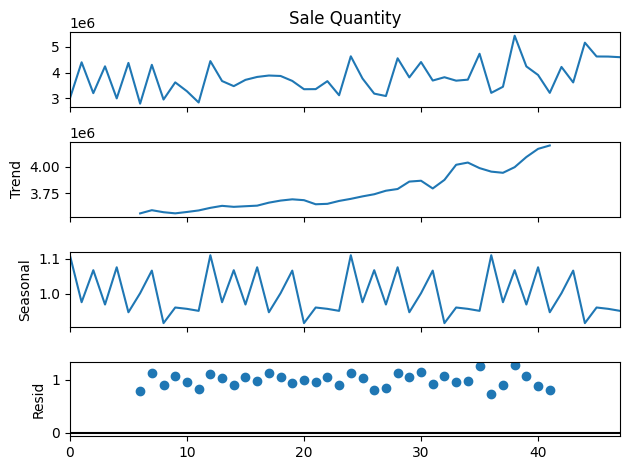

In [41]:
ts_decompose = seasonal_decompose(wsb_df['Sale Quantity'],
                                  model = 'multiplicative',
                                  period = 12)

ts_plot = ts_decompose.plot()
ts_plot.show()

*ARIMA models*

In [43]:
vimana_df = pd.read_csv('vimana.csv')
vimana_df.head(10)

,Month,demand
0,1,457
1,2,439
2,3,404
3,4,392
4,5,403
5,6,371
6,7,382
7,8,358
8,9,594
9,10,482


In [44]:
vimana_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   37 non-null     int64
 1   demand  37 non-null     int64
dtypes: int64(2)
memory usage: 724.0 bytes


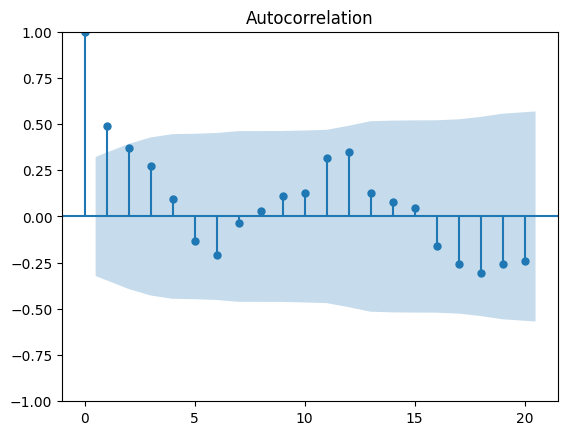

In [49]:
acf_plot = plot_acf(vimana_df['demand'], lags = 20)
acf_plot.show()

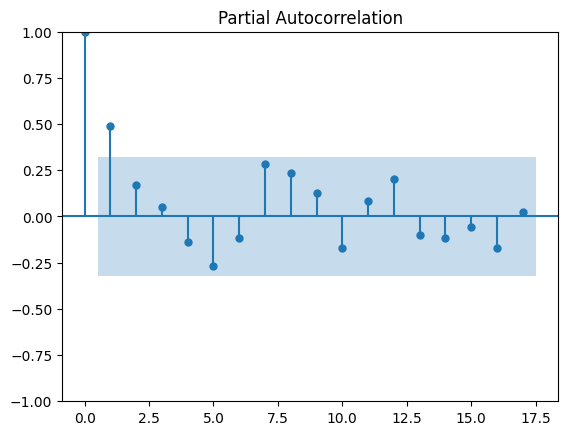

In [51]:
pacf_plot = plot_pacf(vimana_df['demand'], lags = 17)
pacf_plot.show()

*Building AR model*